# Implementacion

# Librerias 

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import janitor as jan
import seaborn as sns

In [2]:
import warnings              
warnings.filterwarnings("ignore") 

# Funciones utilizadas 

In [3]:
def Summary(data, sheet):
    print(f"Hoja: {sheet}")

    # Crear la tabla de resumen
    resumen = {
        "Cantidad de filas": data.shape[0],
        "Cantidad de columnas": data.shape[1],
        "Datos faltantes": data.isnull().sum().sum(),
        "Filas duplicadas": data.duplicated().sum()
    }

    # Convertir el resumen en un DataFrame
    ResumenHoja = pd.DataFrame(resumen, index=["Resumen"])
    print("\nResumen:")
    display(ResumenHoja)

    print("\nEncabezado:")
    display(data.head())

# Cargado de shapefile

Se realiza el cargado del shapefile del DANE correspondiente a los municipios 

In [4]:
shapefile_path = r"C:/Users/User/Documents/DatavizUN/MGN2024_MPIO_POLITICO/MGN_ADM_MPIO_GRAFICO.shp"
gdf = gpd.read_file(shapefile_path, encoding='utf-8')  
gdf.head(n=5)

,dpto_ccdgo,mpio_ccdgo,mpio_cdpmp,dpto_cnmbr,mpio_cnmbr,mpio_crslc,mpio_tipo,mpio_narea,mpio_nano,shape_Leng,shape_Area,geometry
0,05,001,05001,ANTIOQUIA,MEDELLÍN,1965,MUNICIPIO,374.834005,2024,1.035380,0.030608,"POLYGON ((-75.66974 6.3736, -75.66965 6.3736, ..."
1,05,002,05002,ANTIOQUIA,ABEJORRAL,1814,MUNICIPIO,507.141095,2024,1.158504,0.041384,"POLYGON ((-75.46938 5.94575, -75.46897 5.94571..."
2,05,004,05004,ANTIOQUIA,ABRIAQUÍ,1912,MUNICIPIO,296.894050,2024,0.812183,0.024248,"POLYGON ((-76.08351 6.7505, -76.08325 6.75048,..."
3,05,021,05021,ANTIOQUIA,ALEJANDRÍA,Decreto departamental 304 de 1907,MUNICIPIO,128.932153,2024,0.705200,0.010535,"POLYGON ((-75.0332 6.41586, -75.03313 6.41585,..."
4,05,030,05030,ANTIOQUIA,AMAGÁ,1912,MUNICIPIO,84.132477,2024,0.445533,0.006867,"POLYGON ((-75.67587 6.08561, -75.6754 6.08491,..."


Podemos observar que el shapefile descargado contiene el mpio_ccdgo, geometry y mpio_cnmbr

filtramos los municipios de antioquia 

In [5]:
antioquia=gdf[gdf['dpto_cnmbr']=='ANTIOQUIA']
antioquia

,dpto_ccdgo,mpio_ccdgo,mpio_cdpmp,dpto_cnmbr,mpio_cnmbr,mpio_crslc,mpio_tipo,mpio_narea,mpio_nano,shape_Leng,shape_Area,geometry
0,05,001,05001,ANTIOQUIA,MEDELLÍN,1965,MUNICIPIO,374.834005,2024,1.035380,0.030608,"POLYGON ((-75.66974 6.3736, -75.66965 6.3736, ..."
1,05,002,05002,ANTIOQUIA,ABEJORRAL,1814,MUNICIPIO,507.141095,2024,1.158504,0.041384,"POLYGON ((-75.46938 5.94575, -75.46897 5.94571..."
2,05,004,05004,ANTIOQUIA,ABRIAQUÍ,1912,MUNICIPIO,296.894050,2024,0.812183,0.024248,"POLYGON ((-76.08351 6.7505, -76.08325 6.75048,..."
3,05,021,05021,ANTIOQUIA,ALEJANDRÍA,Decreto departamental 304 de 1907,MUNICIPIO,128.932153,2024,0.705200,0.010535,"POLYGON ((-75.0332 6.41586, -75.03313 6.41585,..."
4,05,030,05030,ANTIOQUIA,AMAGÁ,1912,MUNICIPIO,84.132477,2024,0.445533,0.006867,"POLYGON ((-75.67587 6.08561, -75.6754 6.08491,..."
...,...,...,...,...,...,...,...,...,...,...,...,...
120,05,885,05885,ANTIOQUIA,YALÍ,Ordenanza 11 de Noviembrebre 12 de 1959,MUNICIPIO,440.856388,2024,1.419594,0.036051,"POLYGON ((-74.63958 6.79709, -74.63947 6.79702..."
121,05,887,05887,ANTIOQUIA,YARUMAL,1911,MUNICIPIO,712.572037,2024,1.736343,0.058278,"POLYGON ((-75.31703 7.23923, -75.31698 7.23923..."
122,05,890,05890,ANTIOQUIA,YOLOMBÓ,Decreto departamental 384 del 12 de Abril de 1883,MUNICIPIO,943.972083,2024,2.921175,0.077177,"POLYGON ((-75.02661 6.83466, -75.0265 6.83463,..."
123,05,893,05893,ANTIOQUIA,YONDÓ,Ordenanza 38 de Noviembrebre 23 de 1978,MUNICIPIO,1894.981160,2024,2.348293,0.155050,"POLYGON ((-73.92444 7.26587, -73.92436 7.2649,..."


se crea un grafico para revisar que se hizo correctamente 

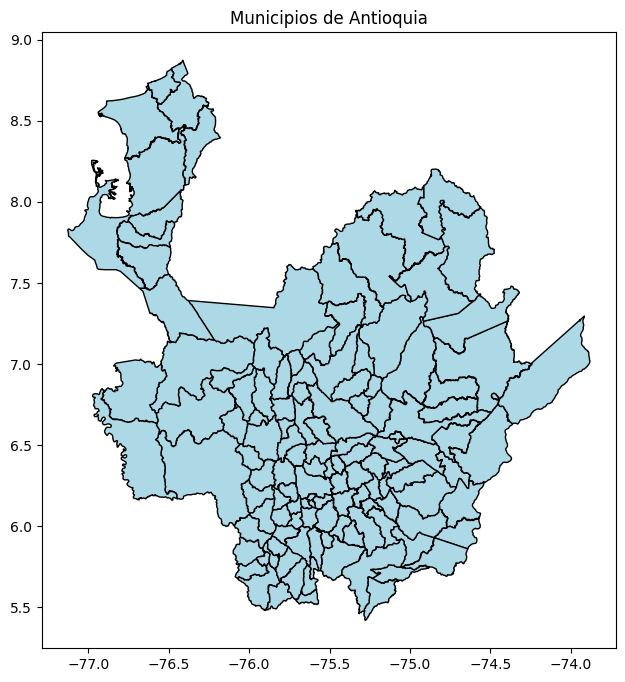

In [6]:
#Grafico del departamento de antioquia y sus municipios
antioquia.plot(edgecolor="black", facecolor="lightblue", figsize=(8,8))
plt.title("Municipios de Antioquia")
plt.show()

Podemos observar que el filtrado se realizo correctamente 

# Cargado del dataset 

In [7]:
df=pd.read_csv('Mortalidad_General_en_el_departamento_de_Antioquia_desde_2005_20250913.csv',sep=',',header=0,encoding='utf-8')

In [8]:
df.head()

,NombreMunicipio,CodigoMunicipio,Ubicacion,NombreRegion,CodigoRegion,Año,NumeroCasos,TasaXMilHabitantes
0,Abejorral,5002,POINT (-75.427045 5.79145),ORIENTE,7,2005,146,7.2
1,Abriaquí,5004,POINT (-76.064563 6.63197),OCCIDENTE,6,2005,13,4.8
2,Alejandría,5021,POINT (-75.141258 6.376923),ORIENTE,7,2005,27,7.1
3,Amagá,5030,POINT (-75.703216 6.04063),SUROESTE,8,2005,137,5.0
4,Amalfi,5031,POINT (-75.075028 6.907385),NORDESTE,4,2005,112,5.5


# Preparacion del dataset 

Se va a revisar primero el dataset antes de realizar cualquier tipo de preparacion

In [9]:
Summary(df,'df')

Hoja: df

Resumen:


,Cantidad de filas,Cantidad de columnas,Datos faltantes,Filas duplicadas
Resumen,2125,8,0,0



Encabezado:


,NombreMunicipio,CodigoMunicipio,Ubicacion,NombreRegion,CodigoRegion,Año,NumeroCasos,TasaXMilHabitantes
0,Abejorral,5002,POINT (-75.427045 5.79145),ORIENTE,7,2005,146,7.2
1,Abriaquí,5004,POINT (-76.064563 6.63197),OCCIDENTE,6,2005,13,4.8
2,Alejandría,5021,POINT (-75.141258 6.376923),ORIENTE,7,2005,27,7.1
3,Amagá,5030,POINT (-75.703216 6.04063),SUROESTE,8,2005,137,5.0
4,Amalfi,5031,POINT (-75.075028 6.907385),NORDESTE,4,2005,112,5.5


In [10]:
df.shape

(2125, 8)

In [11]:
df.columns

Index(['NombreMunicipio', 'CodigoMunicipio', 'Ubicacion', 'NombreRegion',
       'CodigoRegion', 'Año', 'NumeroCasos', 'TasaXMilHabitantes'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2125 entries, 0 to 2124
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   NombreMunicipio     2125 non-null   object 
 1   CodigoMunicipio     2125 non-null   int64  
 2   Ubicacion           2125 non-null   object 
 3   NombreRegion        2125 non-null   object 
 4   CodigoRegion        2125 non-null   int64  
 5   Año                 2125 non-null   int64  
 6   NumeroCasos         2125 non-null   int64  
 7   TasaXMilHabitantes  2125 non-null   float64
dtypes: float64(1), int64(4), object(3)
memory usage: 132.9+ KB


Podemos observar como esta el dataset antes de realizar cualquier preparacion, a partir de ahora se empezara a preparar el dataset para el merge 

In [13]:
#utilizamos janitor para limpiar los nombres de la base de datos 
df=jan.clean_names(df)
df

,nombremunicipio,codigomunicipio,ubicacion,nombreregion,codigoregion,ano,numerocasos,tasaxmilhabitantes
0,Abejorral,5002,POINT (-75.427045 5.79145),ORIENTE,7,2005,146,7.2
1,Abriaquí,5004,POINT (-76.064563 6.63197),OCCIDENTE,6,2005,13,4.8
2,Alejandría,5021,POINT (-75.141258 6.376923),ORIENTE,7,2005,27,7.1
3,Amagá,5030,POINT (-75.703216 6.04063),SUROESTE,8,2005,137,5.0
4,Amalfi,5031,POINT (-75.075028 6.907385),NORDESTE,4,2005,112,5.5
...,...,...,...,...,...,...,...,...
2120,Yalí,5885,POINT (-74.842107 6.675328),NORDESTE,4,2021,56,7.2
2121,Yarumal,5887,POINT (-75.416733 6.963321),NORTE,5,2021,318,7.3
2122,Yolombó,5890,POINT (-75.01183 6.59926),NORDESTE,4,2021,162,6.8
2123,Yondó,5893,POINT (-73.909599 7.007398),MAGDALENA MEDIO,3,2021,122,6.0


In [14]:
#convertir en objetos a variables que fueron importadas como flotantes para realizar una mejor manipulacion
df=df.rename(columns={'ano':'anio'})
df['anio']=df['anio'].astype(object)
df['codigomunicipio']=df['codigomunicipio'].astype(object)
df['codigoregion']=df['codigoregion'].astype(object)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2125 entries, 0 to 2124
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombremunicipio     2125 non-null   object 
 1   codigomunicipio     2125 non-null   object 
 2   ubicacion           2125 non-null   object 
 3   nombreregion        2125 non-null   object 
 4   codigoregion        2125 non-null   object 
 5   anio                2125 non-null   object 
 6   numerocasos         2125 non-null   int64  
 7   tasaxmilhabitantes  2125 non-null   float64
dtypes: float64(1), int64(1), object(6)
memory usage: 132.9+ KB


Podemos observar que los cambios se guardaron correctamente 

revisamos si hay datos faltantes en el dataset

In [15]:
#revision de datos faltantes 
df.isna().sum()

nombremunicipio       0
codigomunicipio       0
ubicacion             0
nombreregion          0
codigoregion          0
anio                  0
numerocasos           0
tasaxmilhabitantes    0
dtype: int64

podemos observar que no habia datos faltantes en el dataset 

revisamos los outliers de la tasaxmilhabitantes 

<Axes: >

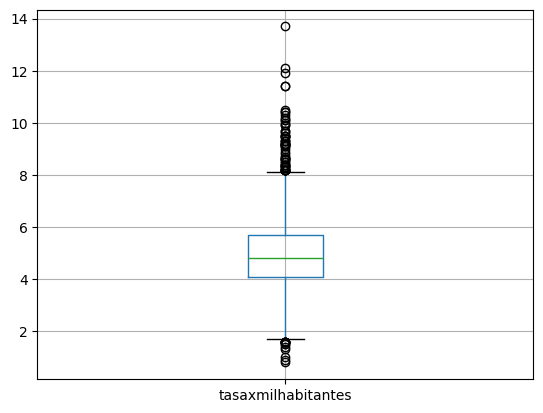

In [16]:
df['tasaxmilhabitantes'].describe()
df.boxplot(column='tasaxmilhabitantes')

Podemos observar que existen valores atipicos en la tasa de mortalidad por mil habitantes, siendo normalmente mayores a 8 en la tasa los que se consideran atipicos, ademas de valores mas bajos 

Revisamos los atipicos mediante el rango intercuartilico

In [17]:
Q1 = df['tasaxmilhabitantes'].quantile(0.25)
Q3 = df['tasaxmilhabitantes'].quantile(0.75)
IQR = Q3 - Q1

# Definir límites
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtrar los outliers
outliers = df[(df['tasaxmilhabitantes'] < limite_inferior) | (df['tasaxmilhabitantes'] > limite_superior)]

# Mostrar las filas con valores atípicos
print(outliers.to_string())

            nombremunicipio codigomunicipio                    ubicacion     nombreregion codigoregion  anio  numerocasos  tasaxmilhabitantes
27                Caramanta            5145  POINT (-75.644483 5.548681)         SUROESTE            8  2005           45                 8.2
32                 Cisneros            5190  POINT (-75.087684 6.538526)         NORDESTE            4  2005           83                 8.6
53                  Granada            5313    POINT (-75.18443 6.14432)          ORIENTE            7  2005           99                10.1
71               Montebello            5467  POINT (-75.524621 5.945694)         SUROESTE            8  2005           69                 9.2
94                 San Luis            5660  POINT (-74.994436 6.042772)          ORIENTE            7  2005          110                10.0
115                Valdivia            5854  POINT (-75.391627 7.292119)            NORTE            5  2005          146                 8.4
144   

Podemos observar que hay datos atipicos mucho mayores y mucho menores de lo usual, sin embargo algunos de estos valores se pueden deber a otros factores como el tamaño de la poblacion del municipio, por lo que no se van a imputar debido a ser casos reales. 

realizamos una descripcion de las variables del dataset usando describe 

In [18]:
#resumen de variables numericas 
round(df.describe(),2)

,numerocasos,tasaxmilhabitantes
count,2125.00,2125.00
mean,253.09,5.01
std,1236.81,1.40
min,5.00,0.80
25%,42.00,4.10
50%,82.00,4.80
75%,157.00,5.70
max,21917.00,13.70


In [19]:
#resumen de variables categoricas 
round(df.describe(include="object"),2)

,nombremunicipio,codigomunicipio,ubicacion,nombreregion,codigoregion,anio
count,2125,2125,2125,2125,2125,2125
unique,125,125,125,9,9,17
top,Abejorral,5002,POINT (-75.427045 5.79145),ORIENTE,7,2005
freq,17,17,17,391,391,125


revisamos el formato de los codigos de los 2 dataset a ver si hay diferencias entre ellos 

In [20]:
#codigo de municipio del df 
codigo_1=df['codigomunicipio']
codigo_1

0       5002
1       5004
2       5021
3       5030
4       5031
        ... 
2120    5885
2121    5887
2122    5890
2123    5893
2124    5895
Name: codigomunicipio, Length: 2125, dtype: object

In [21]:
# codigo de municipios de antioquia del sahpefile 
codigo_2=antioquia['mpio_cdpmp']
codigo_2

0      05001
1      05002
2      05004
3      05021
4      05030
       ...  
120    05885
121    05887
122    05890
123    05893
124    05895
Name: mpio_cdpmp, Length: 125, dtype: object

podemos observar que ambos codigos estan en diferente formato, debemos cambiar la forma en la que se escribe el codigo del dataframe para poder hacer el merge 

In [22]:
#se le añade zfill 5 debido a que es el codigo de municipio
codigo_1= codigo_1.astype(str).str.zfill(5)
codigo_1

0       05002
1       05004
2       05021
3       05030
4       05031
        ...  
2120    05885
2121    05887
2122    05890
2123    05893
2124    05895
Name: codigomunicipio, Length: 2125, dtype: object

Realizamos un groupby antes de realizar el merge para mostrar en el mapa la tasa promedio general de cada municipio y el numero de casos total a lo largo de los años

In [23]:
#se reescribe la variable de codigo municipio con el codigo arrregaldo 
df['codigomunicipio']=codigo_1

In [24]:
#recuperamos la poblacion original en el dataset 
df['poblacion']=df["numerocasos"] * 1000 / df["tasaxmilhabitantes"]

In [25]:
#realizamos el groupby para encontrar los casos totales y la poblacion total
df_agrupado=df.groupby(["codigomunicipio", "nombremunicipio"], as_index=False).agg(
    casos_totales=("numerocasos", "sum"),
    poblacion_total=("poblacion", "sum")
)

In [26]:
#reconstruimos la variable de tasaxmilhabitantes ponderada para usarse en los mapas 
df_agrupado["tasa_x_mil"] = (
    df_agrupado["casos_totales"] / df_agrupado["poblacion_total"] * 1000
)

Se realiza un Barplot de los 10 con mayor tasa ponderada de mortalidad general 

In [27]:
top10 = df_agrupado.nlargest(10, "tasa_x_mil")

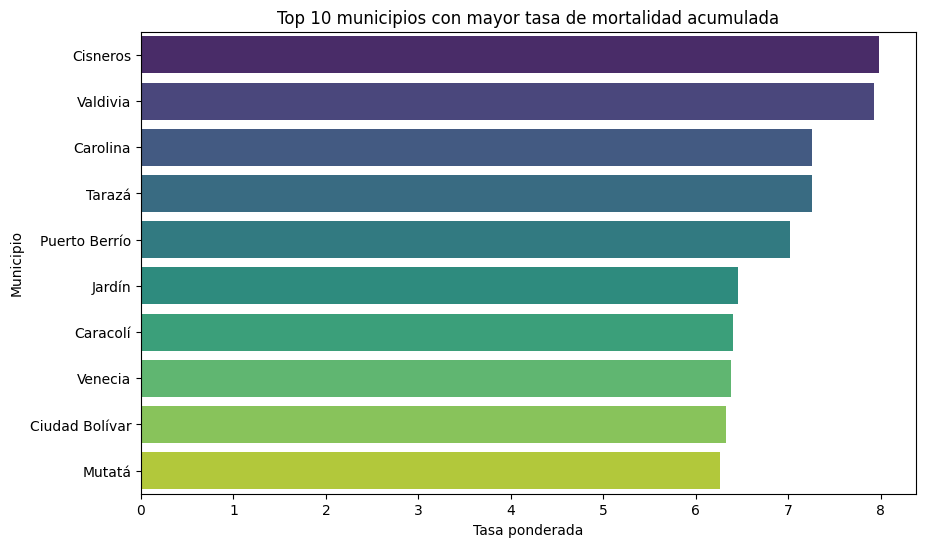

In [28]:
plt.figure(figsize=(10,6))
sns.barplot(data=top10, x="tasa_x_mil", y="nombremunicipio", palette="viridis")
plt.title("Top 10 municipios con mayor tasa de mortalidad acumulada")
plt.xlabel("Tasa ponderada")
plt.ylabel("Municipio")
plt.show()

In [29]:
# Eliminar NombreMunicipio para no duplicar con mpio_cnmbr en el shapefile 
df_agrupado_limpio = df_agrupado.drop(columns="nombremunicipio")

# Merge de los datos

In [30]:
#se hace otro codigo_municipio para realizar el merge 
antioquia['codigomunicipio']=codigo_2

In [31]:
#se hace el merge de los datos 
Datos_tot = pd.merge(antioquia,df_agrupado_limpio, on ='codigomunicipio', how = 'inner')

In [32]:
Datos_tot.head(n=3)

,dpto_ccdgo,mpio_ccdgo,mpio_cdpmp,dpto_cnmbr,mpio_cnmbr,mpio_crslc,mpio_tipo,mpio_narea,mpio_nano,shape_Leng,shape_Area,geometry,codigomunicipio,casos_totales,poblacion_total,tasa_x_mil
0,05,001,05001,ANTIOQUIA,MEDELLÍN,1965,MUNICIPIO,374.834005,2024,1.035380,0.030608,"POLYGON ((-75.66974 6.3736, -75.66965 6.3736, ...",05001,229879,3.899727e+07,5.894747
1,05,002,05002,ANTIOQUIA,ABEJORRAL,1814,MUNICIPIO,507.141095,2024,1.158504,0.041384,"POLYGON ((-75.46938 5.94575, -75.46897 5.94571...",05002,2036,3.589878e+05,5.671502
2,05,004,05004,ANTIOQUIA,ABRIAQUÍ,1912,MUNICIPIO,296.894050,2024,0.812183,0.024248,"POLYGON ((-76.08351 6.7505, -76.08325 6.75048,...",05004,220,4.539414e+04,4.846440


In [33]:
Datos_tot.columns

Index(['dpto_ccdgo', 'mpio_ccdgo', 'mpio_cdpmp', 'dpto_cnmbr', 'mpio_cnmbr',
       'mpio_crslc', 'mpio_tipo', 'mpio_narea', 'mpio_nano', 'shape_Leng',
       'shape_Area', 'geometry', 'codigomunicipio', 'casos_totales',
       'poblacion_total', 'tasa_x_mil'],
      dtype='object')

verificamos si se generaron valores NA

In [34]:
Datos_tot_aux=Datos_tot[['casos_totales','poblacion_total' ,'tasa_x_mil']]

In [35]:
Datos_tot_aux[Datos_tot_aux.isna().any(axis=1)]

,casos_totales,poblacion_total,tasa_x_mil


Podemos observar que no se crearon datos faltantes a la hora de hacer el merge 

# Visualizacion de Graficos coropleticos

se crearon diferentes graficos cloropleticos basados en la variable principal la cual es tasaxmil habitantes ponderada que fue encontrada anteriormente  

In [36]:
antioquia['tasa']=Datos_tot['tasa_x_mil']

([], [])

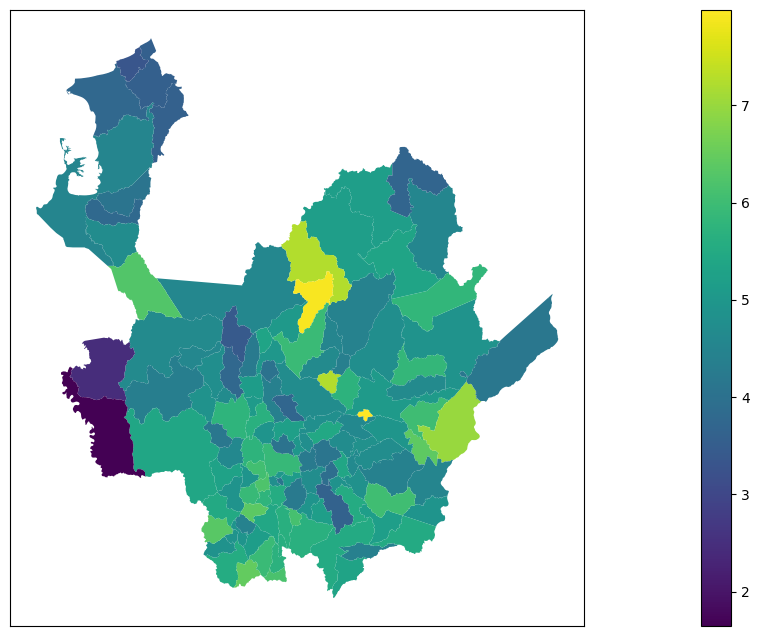

In [37]:
antioquia.plot(column="tasa",figsize=(30,8), legend=True)
plt.xticks([])
plt.yticks([])

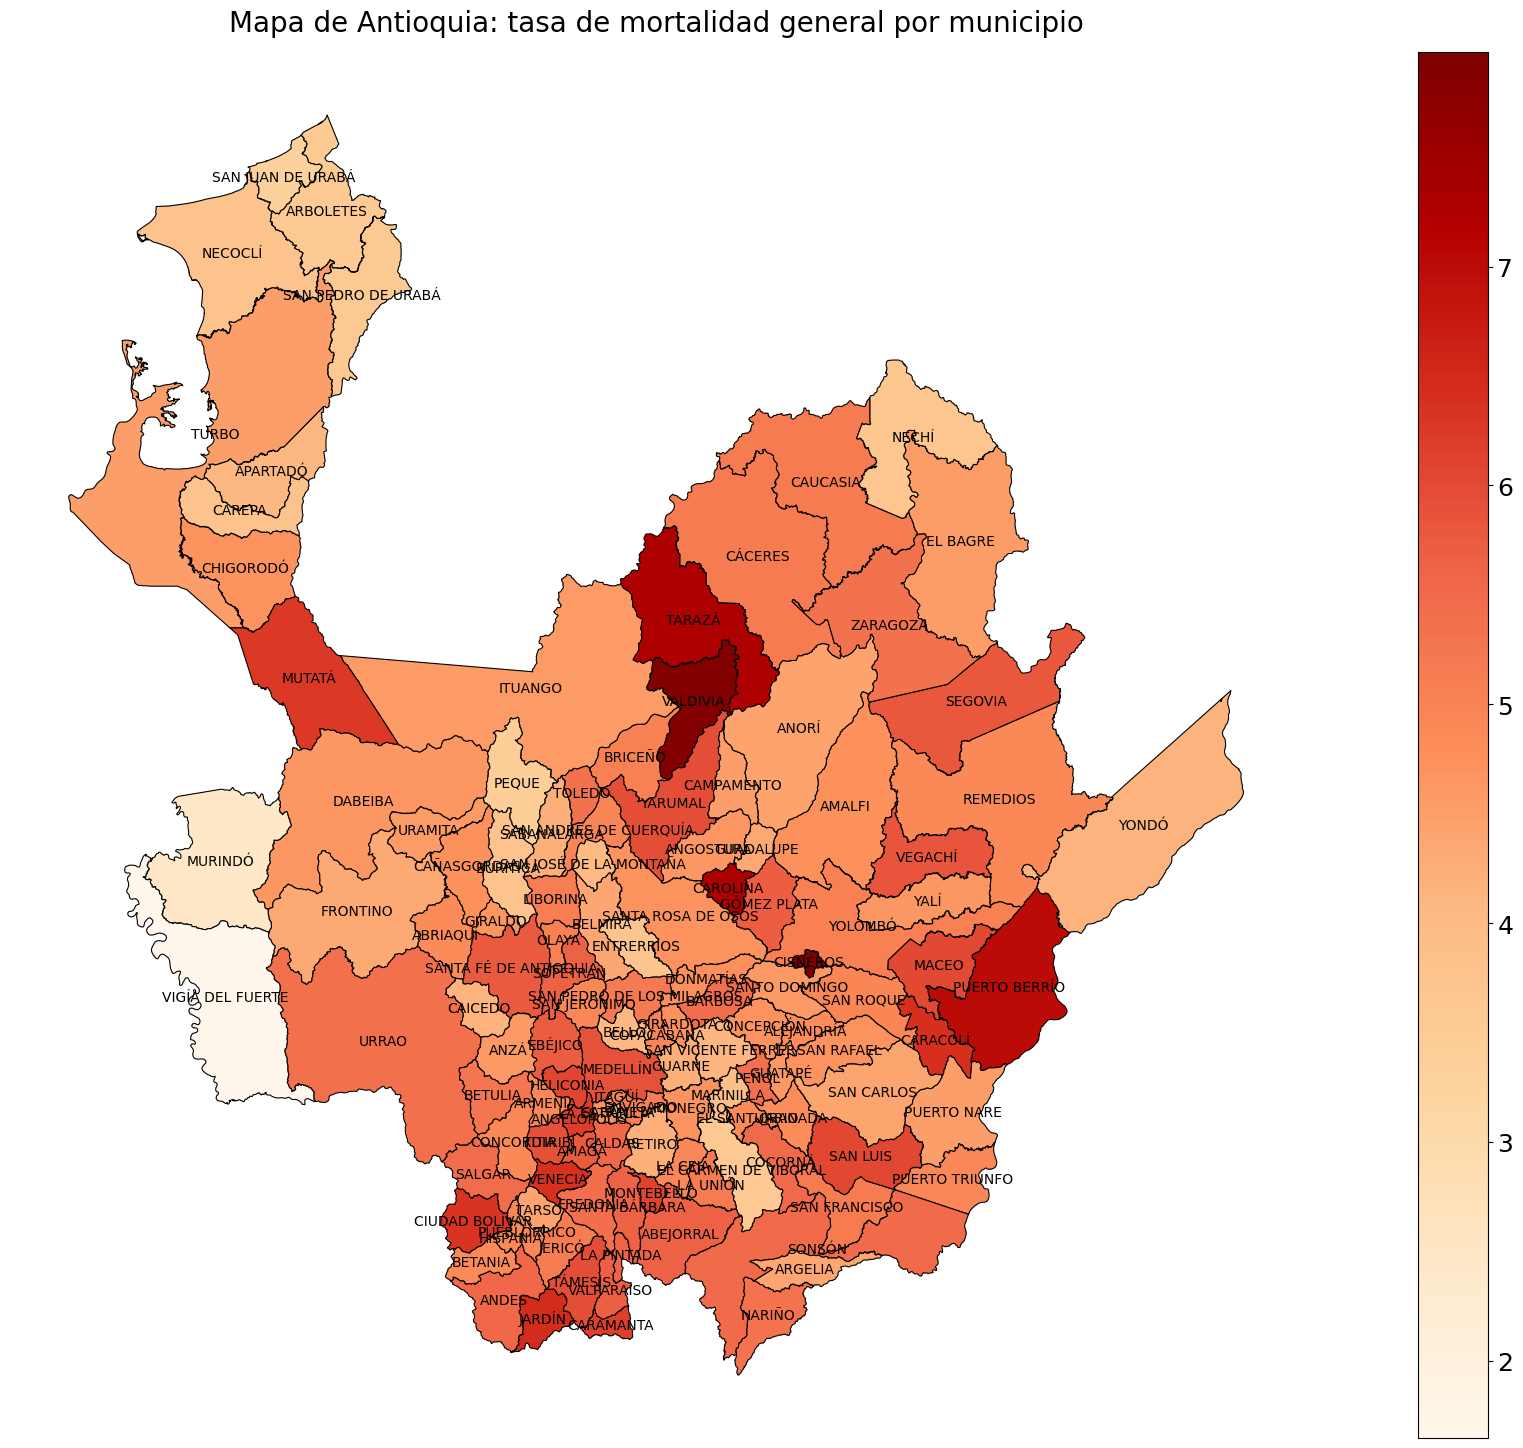

In [38]:
#  Crear figura y ejes
fig, ax = plt.subplots(figsize=(30, 18))

#  Mapa coroplético
antioquia.plot(
    column="tasa",       
    cmap="OrRd",           
    linewidth=0.8,
    ax=ax,
    edgecolor="black",
    legend=True
)

#  Agregar etiquetas
for index, row in antioquia.iterrows():
    xy = row['geometry'].centroid.coords[:]
    plt.annotate(
        row['mpio_cnmbr'],
        xy=xy[0],
        ha='center',
        va='center',
        fontsize=10   
    )
cax = fig.get_axes()[-1]        
cax.tick_params(labelsize=18)   

#  Estética
ax.set_axis_off()
ax.set_title(
    "Mapa de Antioquia: tasa de mortalidad general por municipio",
    pad=15,
    fontsize=20
)

plt.show()


Realizamos ademas graficos con cuantiles y natural breaks para tener un analisis mas completo

Text(0.5, 1.0, 'Tasa de mortalidad general por 1000 hab (Quantiles)')

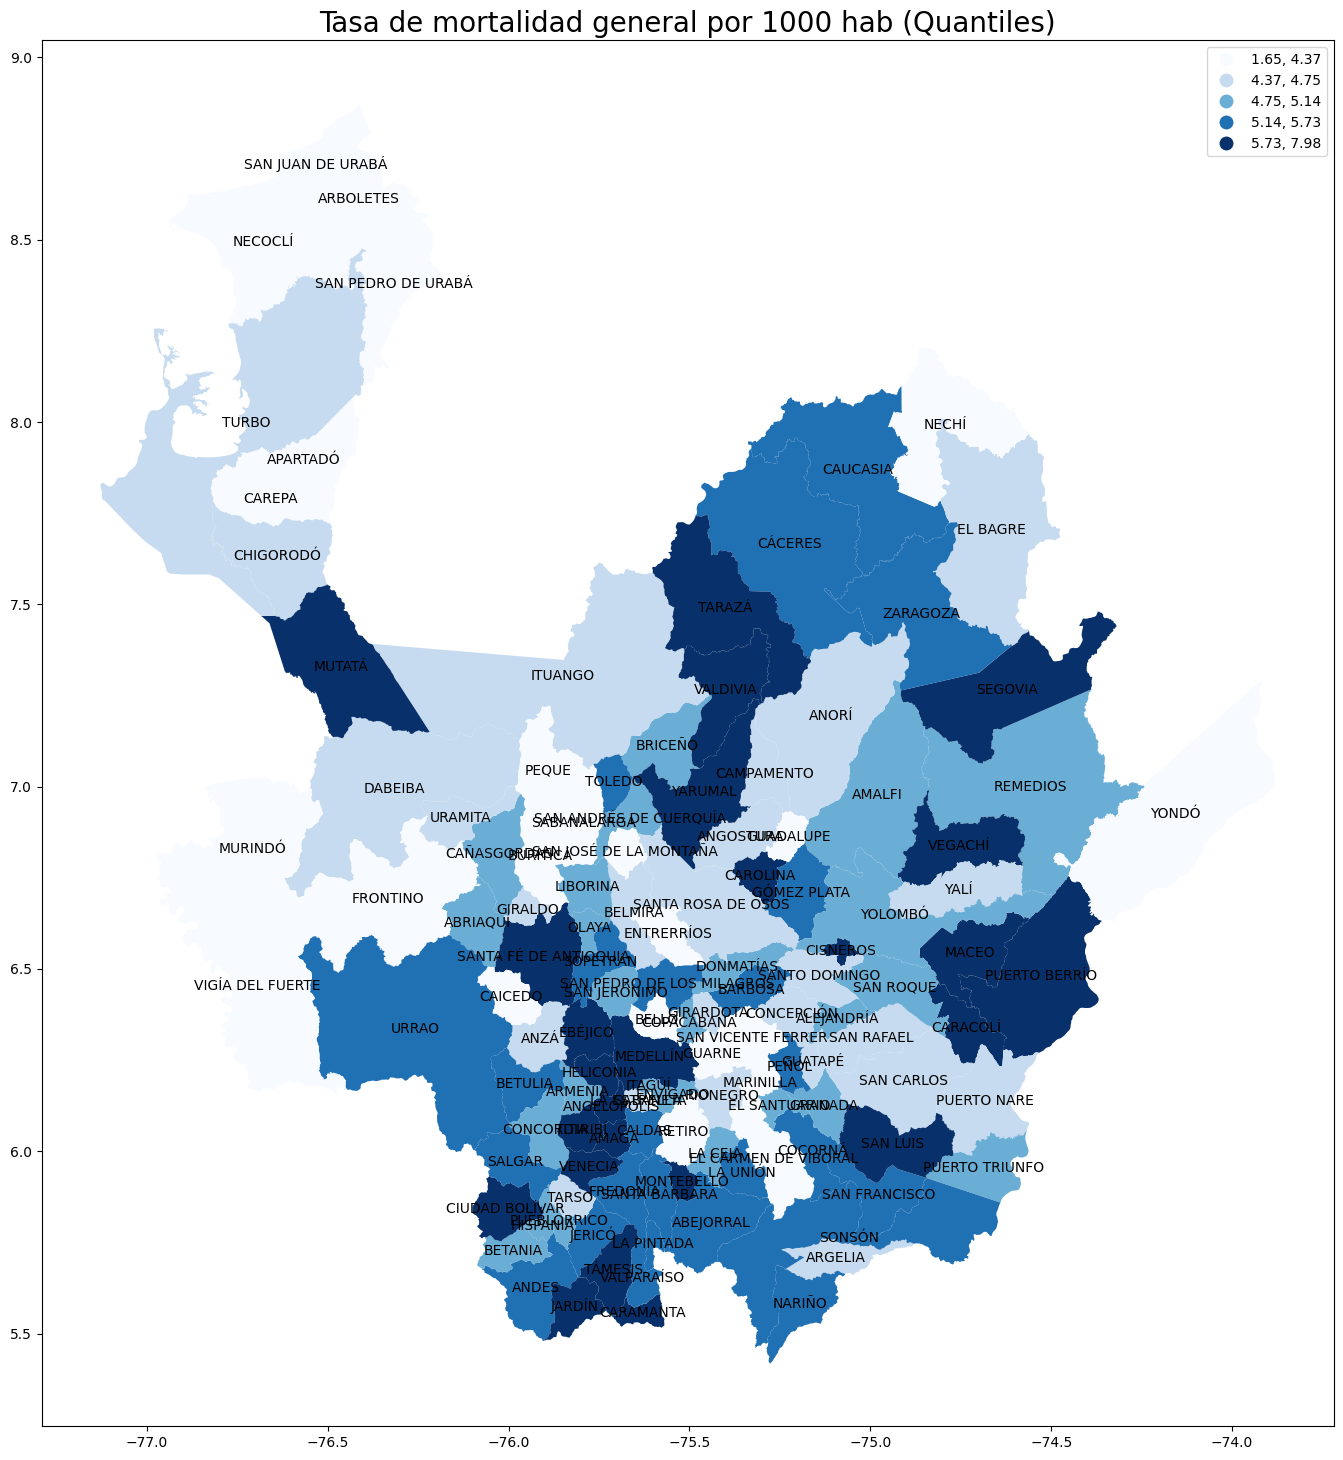

In [39]:
fig, ax = plt.subplots(figsize=(30, 18))
#Mapa con Quantiles 
antioquia.plot(
    column="tasa",
    cmap="Blues",        
    scheme="Quantiles", # clasificación en cuantiles
    k=5,                # número de clases
    legend=True,
    ax=ax
)
for index, row in antioquia.iterrows():
    xy = row['geometry'].centroid.coords[:]
    xytext = row['geometry'].centroid.coords[:]
    plt.annotate(
        row['mpio_cnmbr'],
        xy=xy[0],
        xytext=xytext[0],
        horizontalalignment='center',
        verticalalignment='center'
    )
ax.set_title("Tasa de mortalidad general por 1000 hab (Quantiles)",fontsize=20)


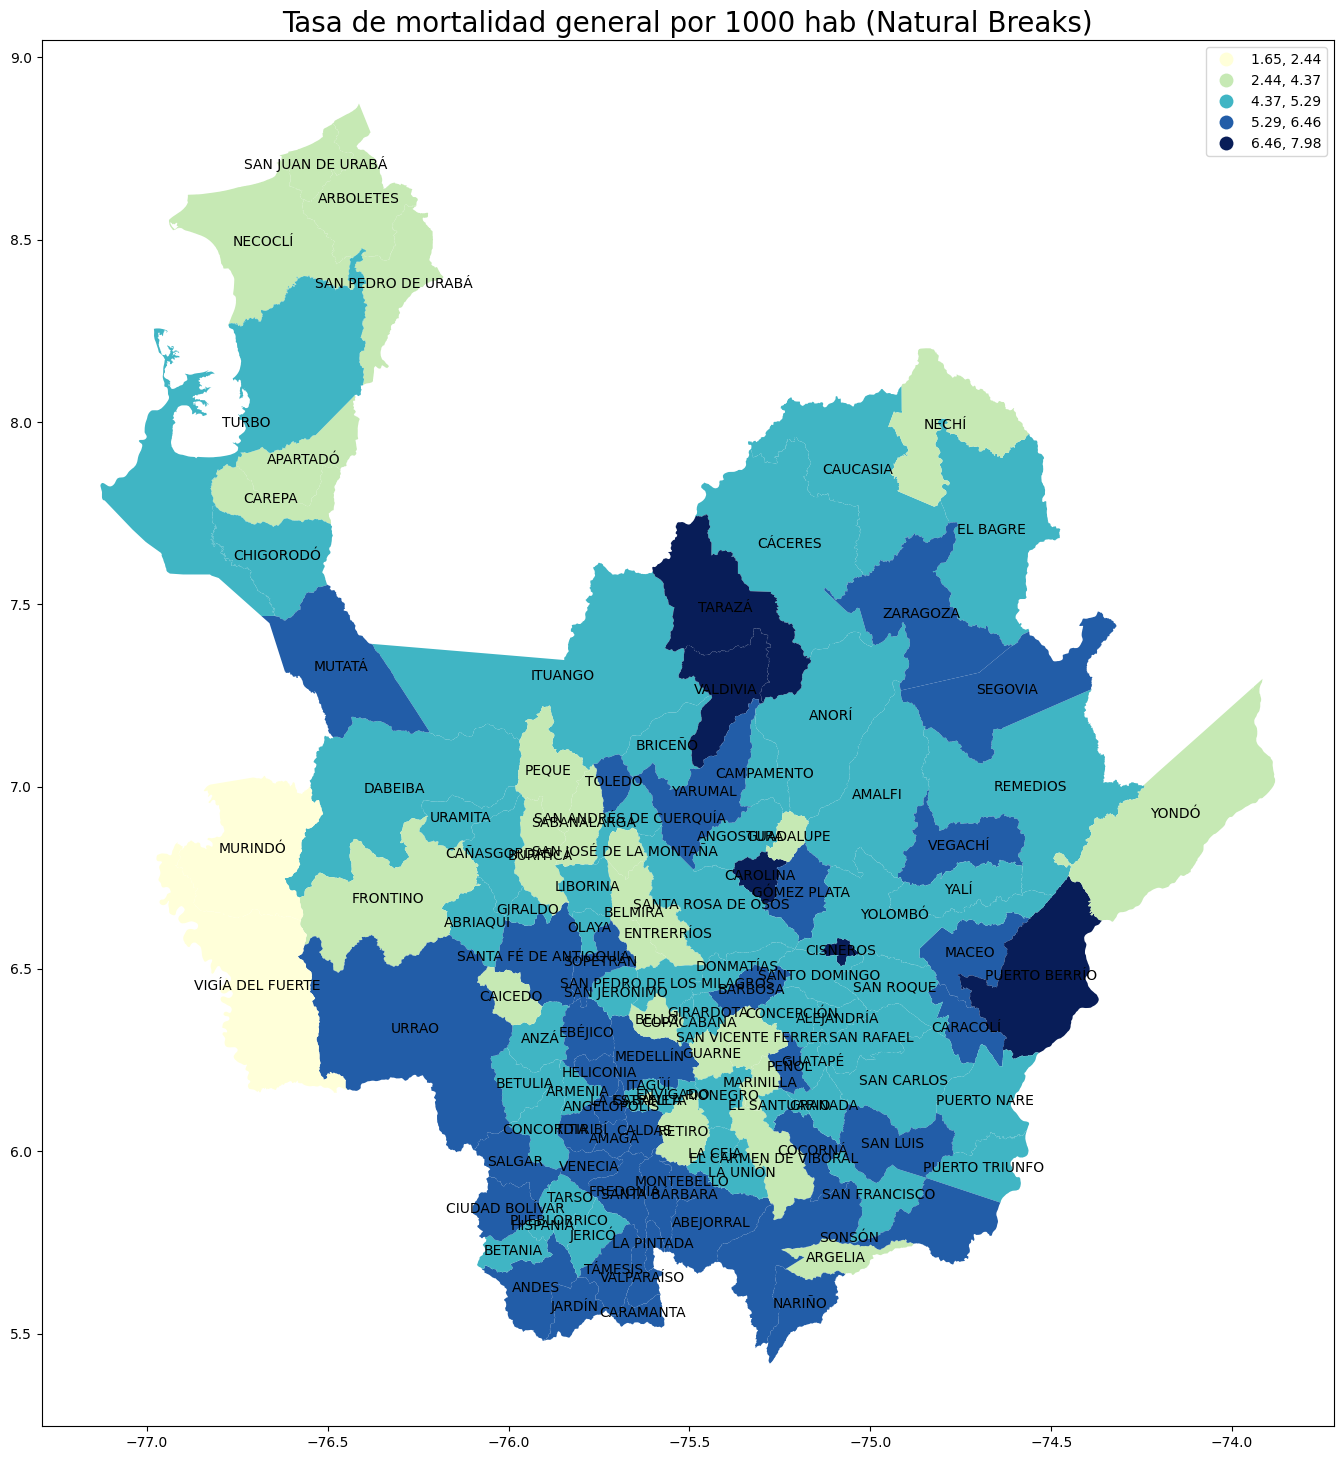

In [40]:
# Mapa con Natural Breaks
fig, ax = plt.subplots(figsize=(30, 18))
antioquia.plot(
    column="tasa",
    cmap="YlGnBu",        
    scheme="NaturalBreaks",
    k=5,
    legend=True,
    ax=ax
)
for index, row in antioquia.iterrows():
    xy = row['geometry'].centroid.coords[:]
    xytext = row['geometry'].centroid.coords[:]
    plt.annotate(
        row['mpio_cnmbr'],
        xy=xy[0],
        xytext=xytext[0],
        horizontalalignment='center',
        verticalalignment='center'
    )
ax.set_title("Tasa de mortalidad general por 1000 hab (Natural Breaks)",fontsize=20)
plt.show()